In [1]:
from __future__ import annotations

import anndata
import pandas as pd
import scanpy as sc
from matplotlib import pyplot as plt

In [2]:
# note that this collection of batches is already intersected on the genes
anndata = sc.read(
    "data/pancreas.h5ad",
    backup_url="https://www.dropbox.com/s/qj1jlm9w10wmt0u/pancreas.h5ad?dl=1",
)
anndata

/anaconda3/envs/bibola/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/anaconda3/envs/bibola/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


AnnData object with n_obs × n_vars = 14693 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [3]:
counts = anndata.obs["celltype"].value_counts()
counts.to_frame()

,count
celltype,
alpha,4214
beta,3354
ductal,1804
acinar,1368
not applicable,1154
delta,917
gamma,571
endothelial,289
activated_stellate,284


In [4]:
minority_classes = counts.index[-5:].tolist()  # get the minority classes
# actually subset
anndata = anndata[~anndata.obs["celltype"].isin(minority_classes)].copy()
# reorder according to abundance
anndata.obs["celltype"] = anndata.obs["celltype"].cat.reorder_categories(counts.index[:-5].tolist())
anndata.obs

,celltype,sample,n_genes,batch,n_counts,louvain
index,,,,,,
human1_lib1.final_cell_0001-0,acinar,Baron,3526,0,2.241100e+04,2
human1_lib1.final_cell_0002-0,acinar,Baron,4201,0,2.794900e+04,2
human1_lib1.final_cell_0003-0,acinar,Baron,2119,0,1.689200e+04,2
human1_lib1.final_cell_0004-0,acinar,Baron,2956,0,1.929900e+04,2
human1_lib1.final_cell_0005-0,acinar,Baron,2715,0,1.506700e+04,2
...,...,...,...,...,...,...
reads.29499-3,ductal,Wang,19950,3,1.056558e+06,10
reads.29500-3,ductal,Wang,19950,3,9.926309e+05,10
reads.29501-3,beta,Wang,19950,3,1.751338e+06,10


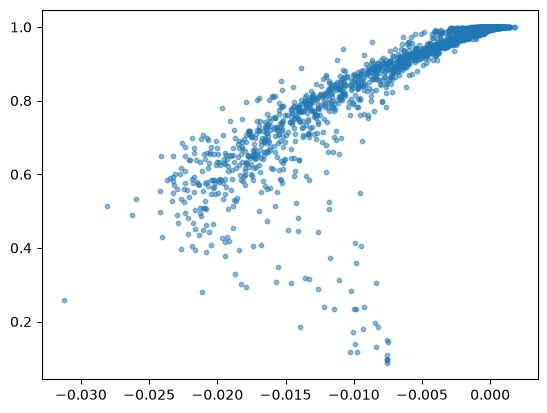

In [5]:
plt.scatter(
    anndata.X.mean(axis=0),
    anndata.X.std(axis=0),
    alpha=.5, s=10
)
plt.show()

In [6]:
sc.pp.pca(anndata)
sc.pp.neighbors(anndata)
sc.tl.umap(anndata)

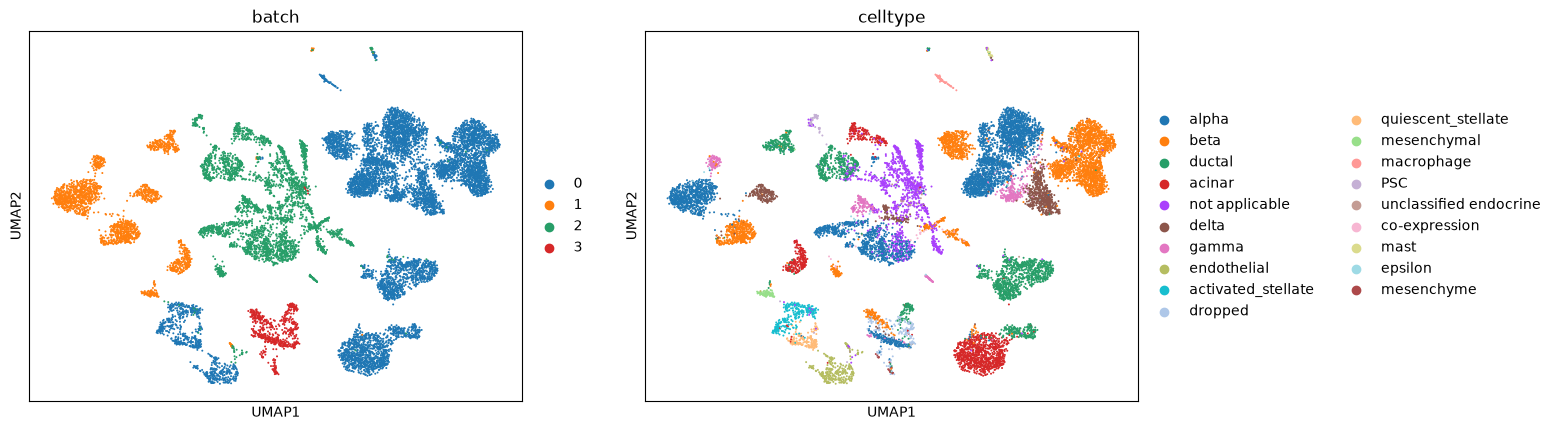

In [7]:
# original UMAP (without batch correction)
sc.pl.umap(anndata, color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)

In [8]:
import torch

from bibola.model import ChunkIntegration

In [9]:
batch_correction_model = ChunkIntegration(
    in_channels=anndata.obsm["X_pca"].shape[1],
    hidden_channels=[128,],
    out_channels=50,
    dropout=0.1,
    optimizer_kwargs={"lr": 1e-3}
)
batch_correction_model

ChunkIntegration(in_channels=50, hidden_channels=[128], out_channels=50, optimizer=Adam, not fitted)

In [10]:
batch_correction_model.fit(
    anndata.obsm["X_pca"], anndata.obs["batch"], epochs=5,
    print_every=1, k_inter=5, k_intra=100, norm=1,
    loss_weights={"abs_lisa_loss":1., "topology_loss":1., "knn_loss":1., "reconstruction_loss":1.},
    n_chunks=5
)

Epoch 1/5 - total_loss=-0.0382 (abs_lisa_loss=0.0426, topology_loss=-0.9005, knn_loss=-0.2921, reconstruction_loss=0.9970)
Epoch 2/5 - total_loss=-0.0825 (abs_lisa_loss=0.0287, topology_loss=-0.9120, knn_loss=-0.4158, reconstruction_loss=0.9691)
Epoch 3/5 - total_loss=-0.1132 (abs_lisa_loss=0.0238, topology_loss=-0.9076, knn_loss=-0.5167, reconstruction_loss=0.9476)
Epoch 4/5 - total_loss=-0.1341 (abs_lisa_loss=0.0205, topology_loss=-0.8977, knn_loss=-0.5894, reconstruction_loss=0.9303)
Epoch 5/5 - total_loss=-0.1482 (abs_lisa_loss=0.0195, topology_loss=-0.8868, knn_loss=-0.6403, reconstruction_loss=0.9147)


In [11]:
batch_correction_model.loss_history

loss                                              loss_weights  \
  abs_lisa_loss topology_loss  knn_loss reconstruction_loss abs_lisa_loss   
0      0.042628     -0.900516 -0.292056            0.996968           1.0   
1      0.028683     -0.911954 -0.415768            0.969056           1.0   
2      0.023814     -0.907606 -0.516667            0.947600           1.0   
3      0.020538     -0.897706 -0.589350            0.930308           1.0   
4      0.019488     -0.886823 -0.640292            0.914727           1.0   

                                              
  topology_loss knn_loss reconstruction_loss  
0           1.0      1.0                 1.0  
1           1.0      1.0                 1.0  
2           1.0      1.0                 1.0  
3           1.0      1.0                 1.0  
4           1.0      1.0                 1.0

In [12]:
anndata.obsm["X_corrected"] = batch_correction_model.transform(
    anndata.obsm["X_pca"], anndata.obs["batch"]
).numpy()

from sklearn.decomposition import PCA

# we apply PCA to reduce the collinearity after the batch correction.
pca_model = PCA(n_components=50)
anndata.obsm["X_corrected"] = pca_model.fit_transform(anndata.obsm["X_corrected"])
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors'
    obsm: 'X_pca', 'X_umap', 'X_corrected'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [13]:
sc.pp.neighbors(anndata, use_rep="X_corrected", key_added="neighbors_corrected")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected", key_added="umap_corrected")
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities'

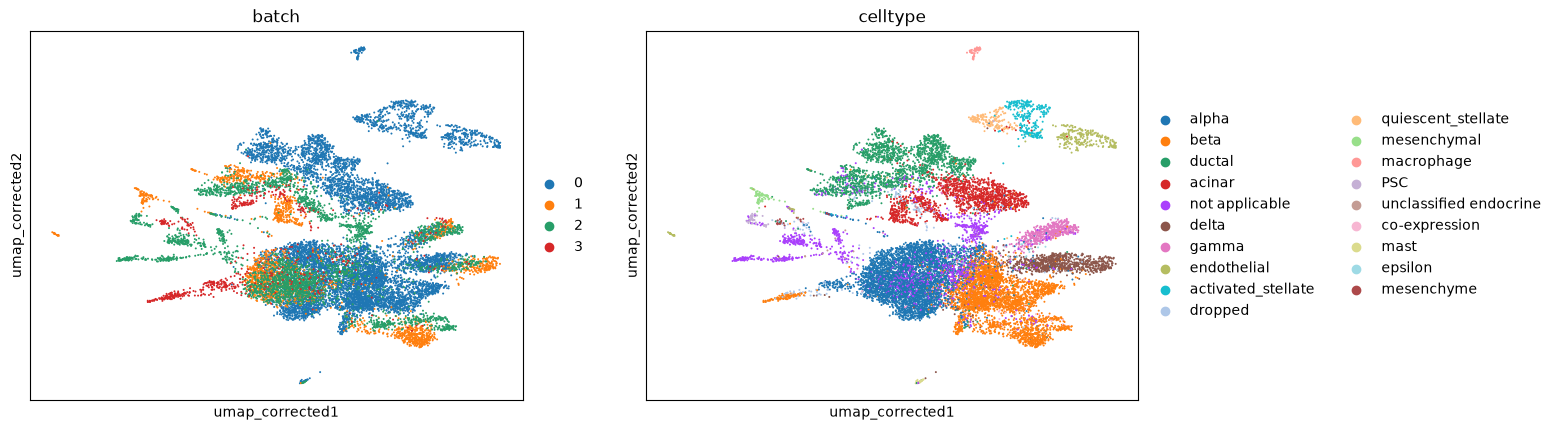

In [14]:
sc.pl.embedding(anndata, basis="umap_corrected", color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after batch correction via bibola

In [15]:
anndata.obsm["X_pca_reconstructed"] = batch_correction_model.reconstruct(anndata.obsm["X_pca"], anndata.obs["batch"]).numpy()
sc.pp.neighbors(anndata, use_rep="X_pca_reconstructed", key_added="neighbors_reconstructed")
sc.tl.umap(anndata, neighbors_key="neighbors_reconstructed", key_added="umap_reconstructed")
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected', 'neighbors_reconstructed', 'umap_reconstructed'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected', 'X_pca_reconstructed', 'umap_reconstructed'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_reconstructed_distances', 'neighbors_reconstructed_connectivities'

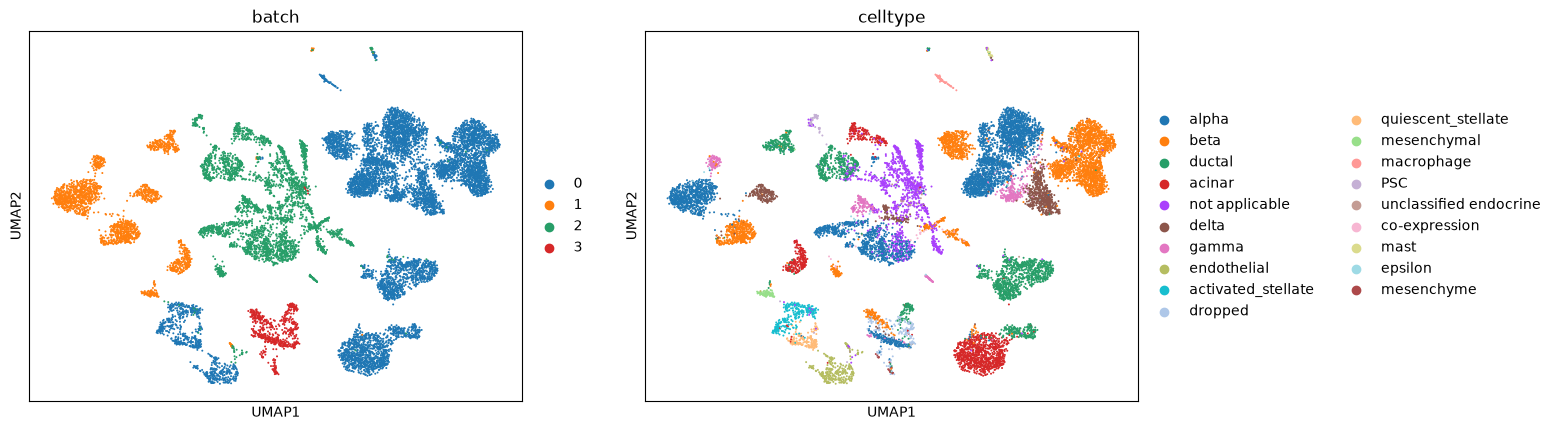

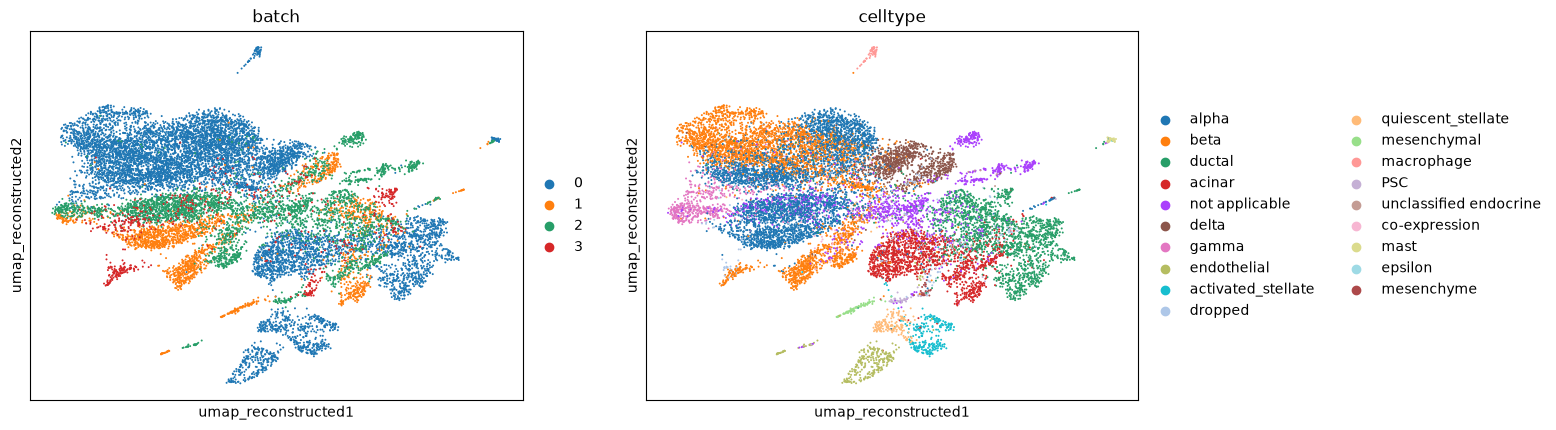

In [16]:
sc.pl.embedding(anndata, basis="umap", color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)
sc.pl.embedding(anndata, basis="umap_reconstructed", color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after reconstruction (should be similar to the original UMAP)

In [17]:
from harmonypy import run_harmony

In [18]:
anndata.obsm["X_pca_harmony"] = run_harmony(anndata.obsm["X_pca"], anndata.obs, "batch").Z_corr
anndata.obsm["X_pca_harmony"]

2026-08-14 12:09:52,801 - harmonypy - INFO - Running Harmony
2026-08-14 12:09:52,802 - harmonypy - INFO -   Parameters:
2026-08-14 12:09:52,802 - harmonypy - INFO -     max_iter_harmony: 10
2026-08-14 12:09:52,802 - harmonypy - INFO -     max_iter_kmeans: 4
2026-08-14 12:09:52,803 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-08-14 12:09:52,803 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-08-14 12:09:52,803 - harmonypy - INFO -     nclust: 100
2026-08-14 12:09:52,803 - harmonypy - INFO -     block_size: 0.05
2026-08-14 12:09:52,803 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-08-14 12:09:52,804 - harmonypy - INFO -     theta: [2. 2. 2. 2.]
2026-08-14 12:09:52,804 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-14 12:09:52,805 - harmonypy - INFO -     verbose: True
2026-08-14 12:09:52,805 - harmonypy - INFO -     random_state: 0
2026-08-14 12:09:52,805 - harmonypy - INFO -   Data: 50 PCs × 14662 cells
2026-08-14 12:09:52,806 - harmonypy - INFO -

array([[  0.15425171,  -4.53972244,  -8.52065468, ...,  -0.38841876,
         -1.45698595,   0.08615991],
       [  3.89552402,  -4.51804066, -10.26223946, ...,  -1.12404025,
          0.90807426,   0.02703966],
       [ -3.71449828,  -4.54087257,  -6.43288279, ...,  -0.76113915,
          0.75945079,   0.08842079],
       ...,
       [  2.96661663,  10.92668152,   5.37792253, ...,   4.19615793,
          1.68354046,   0.28366753],
       [ 14.31705666,  -1.82588816, -12.1900053 , ...,   1.48150325,
          0.90651804,   1.02317023],
       [  3.00160837,  12.04156685,   4.41478348, ...,   0.0424562 ,
          0.6069088 ,   1.26845121]], shape=(14662, 50))

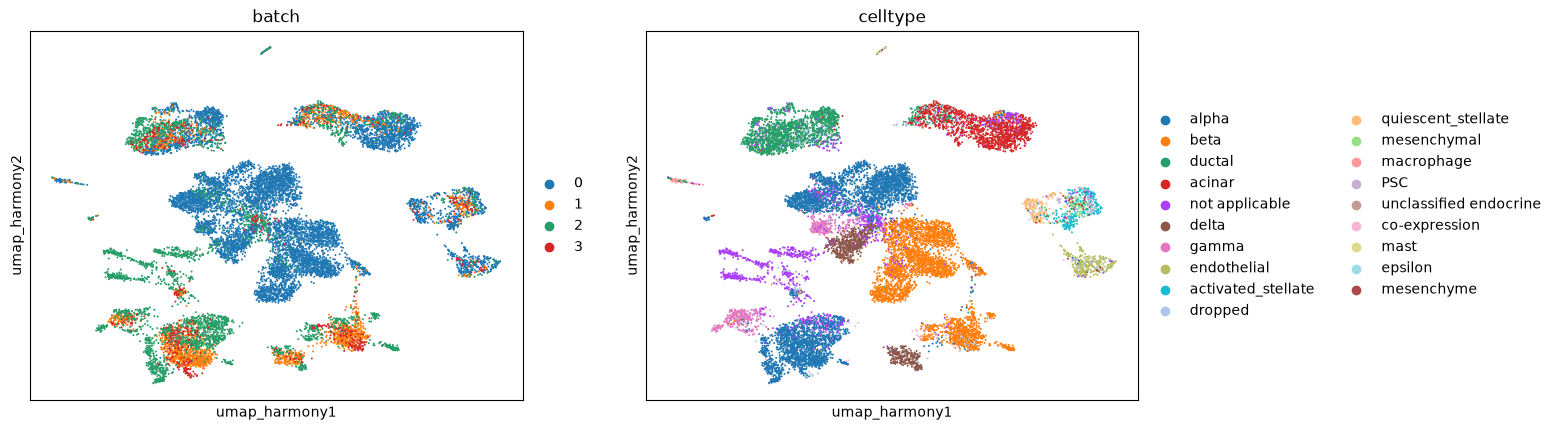

In [19]:
sc.pp.neighbors(anndata, use_rep="X_pca_harmony", key_added="neighbors_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_harmony", key_added="umap_harmony")
sc.pl.embedding(anndata, color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy, basis="umap_harmony")
# UMAP after batch correction via harmony

In [20]:
# We can even consider to run the bibola workflow starting from harmony correction, instead of PCA.
# This in order to have a warmer initializzation of the gradient, since the data is already well integrated and we just need to refine the integration at a local level..
# In this case, we will prioritize the spatial autocorrelation (LIBSA) loss since the batches are already "close" enough.

In [21]:
batch_correction_model = ChunkIntegration(
    in_channels=anndata.obsm["X_pca_harmony"].shape[1],
    hidden_channels=[128,],
    out_channels=50,
    dropout=0.1,
    optimizer_kwargs={"lr": 1e-3}
)
batch_correction_model

ChunkIntegration(in_channels=50, hidden_channels=[128], out_channels=50, optimizer=Adam, not fitted)

In [22]:
batch_correction_model.fit(
    anndata.obsm["X_pca_harmony"], anndata.obs["batch"], epochs=5,
    print_every=1, k_inter=5, k_intra=100, norm=1,
    loss_weights={"abs_lisa_loss":1, "topology_loss":1, "knn_loss": 1, "reconstruction_loss":1.},
    n_chunks=5
)

Epoch 1/5 - total_loss=-0.0307 (abs_lisa_loss=0.0340, topology_loss=-0.8860, knn_loss=-0.2736, reconstruction_loss=1.0030)
Epoch 2/5 - total_loss=-0.0708 (abs_lisa_loss=0.0225, topology_loss=-0.9029, knn_loss=-0.3743, reconstruction_loss=0.9715)
Epoch 3/5 - total_loss=-0.0995 (abs_lisa_loss=0.0175, topology_loss=-0.9024, knn_loss=-0.4585, reconstruction_loss=0.9454)
Epoch 4/5 - total_loss=-0.1206 (abs_lisa_loss=0.0145, topology_loss=-0.8954, knn_loss=-0.5253, reconstruction_loss=0.9239)
Epoch 5/5 - total_loss=-0.1377 (abs_lisa_loss=0.0131, topology_loss=-0.8881, knn_loss=-0.5807, reconstruction_loss=0.9048)


In [23]:
batch_correction_model.loss_history

loss                                              loss_weights  \
  abs_lisa_loss topology_loss  knn_loss reconstruction_loss abs_lisa_loss   
0      0.033973     -0.885981 -0.273595            1.002967             1   
1      0.022497     -0.902883 -0.374259            0.971495             1   
2      0.017529     -0.902446 -0.458529            0.945447             1   
3      0.014497     -0.895434 -0.525321            0.923921             1   
4      0.013076     -0.888091 -0.580666            0.904760             1   

                                              
  topology_loss knn_loss reconstruction_loss  
0             1        1                 1.0  
1             1        1                 1.0  
2             1        1                 1.0  
3             1        1                 1.0  
4             1        1                 1.0

In [24]:
anndata.obsm["X_corrected_after_harmony"] = batch_correction_model.transform(
    anndata.obsm["X_pca_harmony"], anndata.obs["batch"]
).numpy()

from sklearn.decomposition import PCA

pca_model = PCA(n_components=50)
anndata.obsm["X_corrected_after_harmony"] = pca_model.fit_transform(anndata.obsm["X_corrected_after_harmony"])
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected', 'neighbors_reconstructed', 'umap_reconstructed', 'neighbors_harmony', 'umap_harmony'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected', 'X_pca_reconstructed', 'umap_reconstructed', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_reconstructed_distances', 'neighbors_reconstructed_connectivities', 'neighbors_harmony_distances', 'neighbors_harmony_connectivities'

In [25]:
sc.pp.neighbors(anndata, use_rep="X_corrected_after_harmony", key_added="neighbors_corrected_after_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected_after_harmony", key_added="umap_corrected_after_harmony")
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected', 'neighbors_reconstructed', 'umap_reconstructed', 'neighbors_harmony', 'umap_harmony', 'neighbors_corrected_after_harmony', 'umap_corrected_after_harmony'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected', 'X_pca_reconstructed', 'umap_reconstructed', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony', 'umap_corrected_after_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_reconstructed_distances', 'neighbors_reconstructed_connectivities', 'neighbors_harmony_distances', 'neighbors_harmony_connectivities', 'neighbors_corrected_after_harmony_distances', '

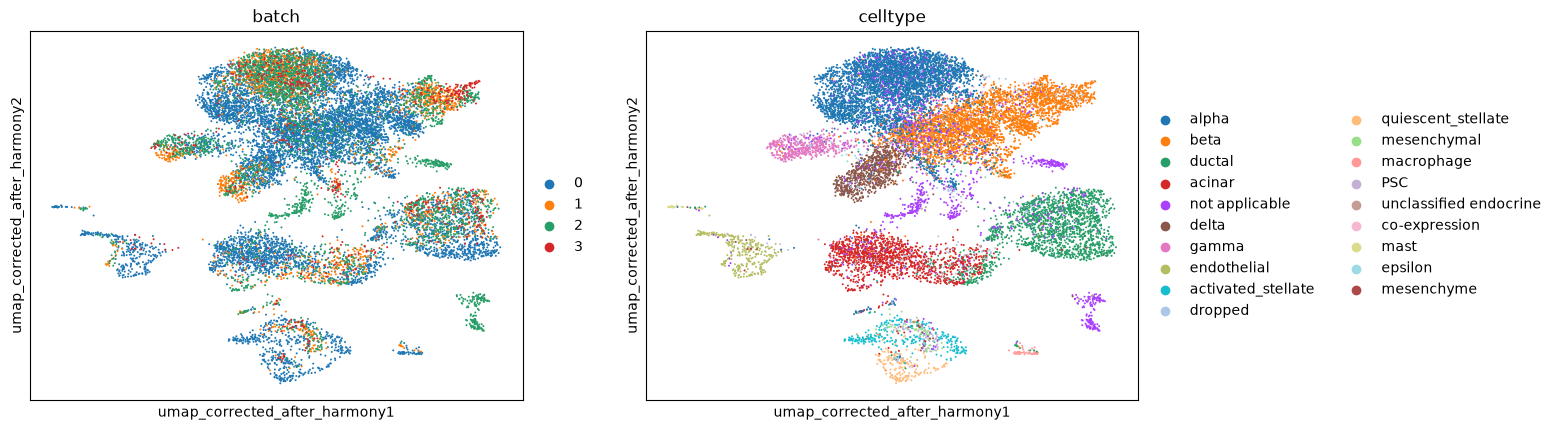

In [26]:
sc.pl.embedding(anndata, basis="umap_corrected_after_harmony", color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after batch correction via bibola, starting from harmony
# we see an improvement in the integration of the batches, and a better separation of the cell types, compared to harmony alone.